# Song Genre Classification

# Install Dependencies

*   Use the T4 GPU Runtime


In [ ]:
!pip install nltk kagglehub scikit-learn xgboost --quiet

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import scipy.sparse as sp
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import nltk
from sklearn.utils import resample
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.utils import resample
nltk.download('stopwords')
nltk.download('wordnet')

import kagglehub

# Dataset link: https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information/song_lyrics.csv"
# Download latest version
path = kagglehub.dataset_download('carlosgdcj/genius-song-lyrics-with-language-information')

print('Path to dataset files:', path)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


100%|██████████| 3.04G/3.04G [01:30<00:00, 36.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/carlosgdcj/genius-song-lyrics-with-language-information/versions/1


# EDA

In [ ]:
# =========================
# Dataset columns
# =========================
TEXT_COL = "lyrics"
TAG_COL = "tag"
LANG_COL = "language"

# =========================
# Load data
# =========================
df = pd.read_csv(f'{path}/song_lyrics.csv', nrows=200000)

features = ["artist", "lyrics", "tag", "language"]
df = df[features].copy()

# =========================
# Filter out non-english
# =========================
df = df[df[LANG_COL] == "en"].copy()

print("\n=== Columns and dtypes after filtering language == 'en' ===")
print(df.dtypes)

print("\n=== Number of unique values in tag BEFORE removing 'misc' ===")
print(df[TAG_COL].nunique(dropna=True))

# =========================
# Remove "misc" tag
# =========================
df = df[df[TAG_COL] != "misc"].copy()

print("\n=== Number of records after removing tag == 'misc' ===")
print(len(df))

print("\n=== Distribution of tag values ===")
tag_counts = df[TAG_COL].value_counts(dropna=False)
print(tag_counts)




=== Columns and dtypes after filtering language == 'en' ===
artist      object
lyrics      object
tag         object
language    object
dtype: object

=== Number of unique values in tag BEFORE removing 'misc' ===
6

=== Number of records after removing tag == 'misc' ===
135177

=== Distribution of tag values ===
tag
rap        107598
rock        17248
pop          4651
country      3251
rb           2429
Name: count, dtype: int64


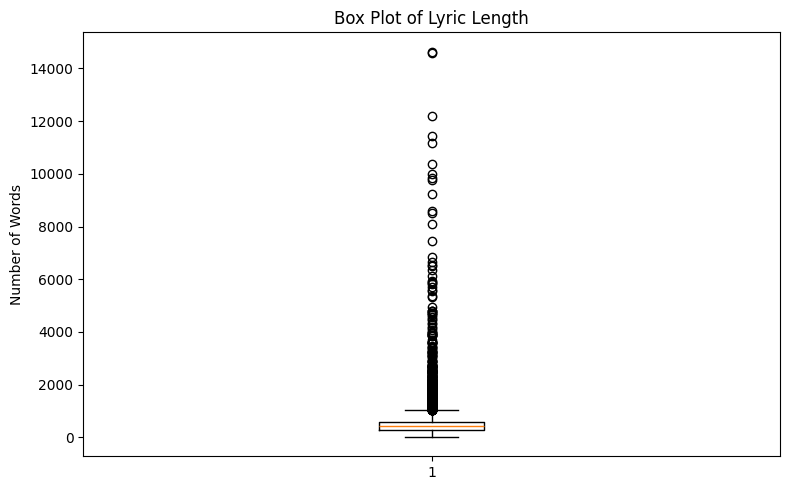


=== Lyric length summary ===
count    135177.000000
mean        461.571599
std         265.391813
min          11.000000
25%         291.000000
50%         445.000000
75%         596.000000
max       14641.000000
Name: lyric_length, dtype: float64


In [ ]:
# =========================
# Lyric length feature
# =========================
# word count version
df["lyric_length"] = df[TEXT_COL].fillna("").astype(str).str.split().str.len()

# =========================
# Box plot of lyric length
# =========================
plt.figure(figsize=(8, 5))
plt.boxplot(df["lyric_length"].dropna())
plt.title("Box Plot of Lyric Length")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

print("\n=== Lyric length summary ===")
print(df["lyric_length"].describe())

/tmp/ipykernel_3724/141778874.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(genre_data, patch_artist=True, labels=genres)


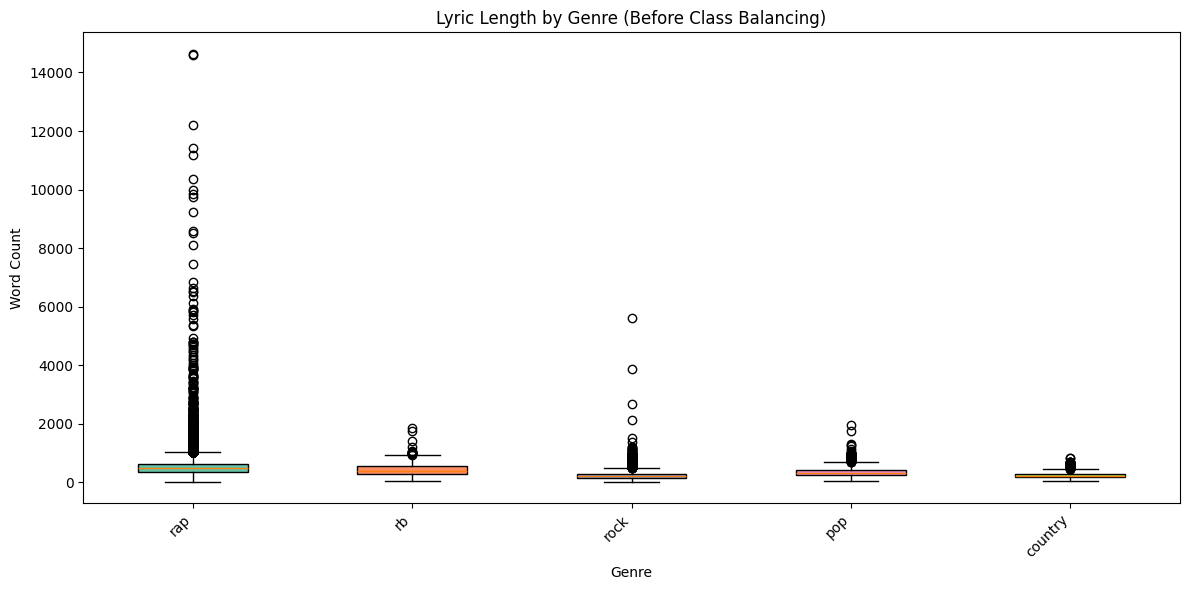

In [ ]:
# Lyric Length Box Plot by Genre (colored)
genres = df[TAG_COL].unique()
colors = plt.cm.Set2.colors[:len(genres)]  # distinct color per genre

fig, ax = plt.subplots(figsize=(12, 6))

genre_data = [df[df[TAG_COL] == g]['lyric_length'].dropna().values for g in genres]

bp = ax.boxplot(genre_data, patch_artist=True, labels=genres)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Lyric Length by Genre (Before Class Balancing)')
ax.set_xlabel('Genre')
ax.set_ylabel('Word Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

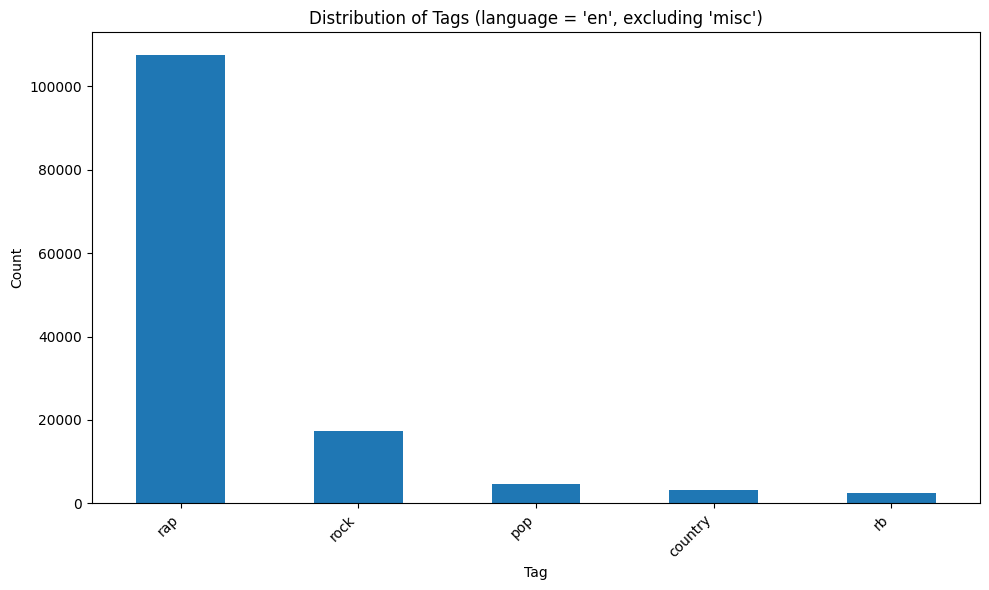

In [ ]:
# =========================
# Tag distribution
# =========================
plt.figure(figsize=(10, 6))
tag_counts.plot(kind="bar")
plt.title("Distribution of Tags (language = 'en', excluding 'misc')")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

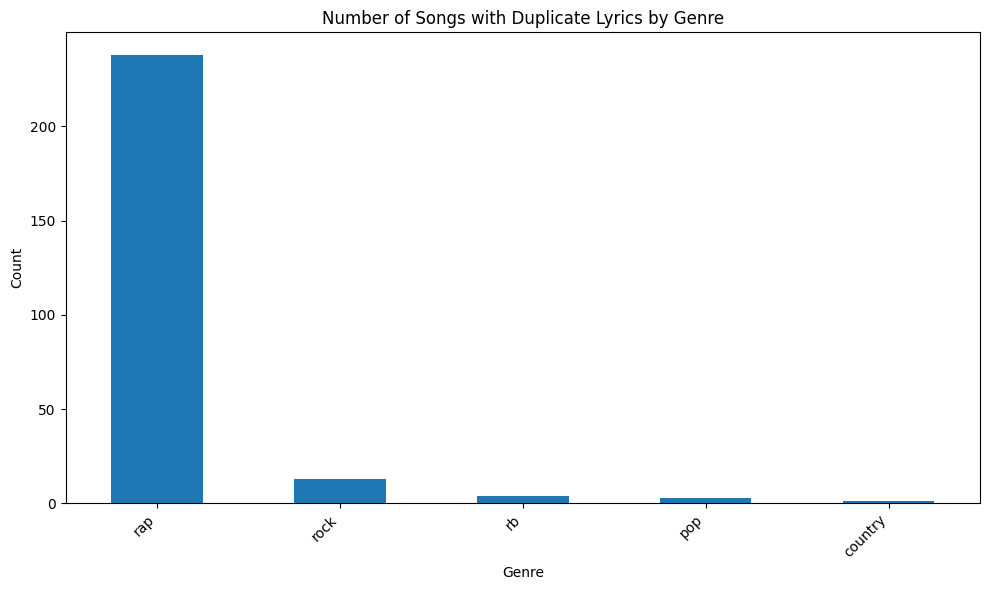


=== Duplicate lyric counts by genre ===
tag
rap        238
rock        13
rb           4
pop          3
country      1
Name: count, dtype: int64


In [ ]:
# =========================
# Duplicate Lyrics by Genre
# =========================
# Songs that share exact lyrics with at least one other song (potential covers)
dupes_by_tag = df[df.duplicated(subset=[TEXT_COL], keep=False)]

tag_dupe_counts = dupes_by_tag[TAG_COL].value_counts()

plt.figure(figsize=(10, 6))
tag_dupe_counts.plot(kind="bar")
plt.title("Number of Songs with Duplicate Lyrics by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n=== Duplicate lyric counts by genre ===")
print(tag_dupe_counts)

# Preprocessing

artist          0
lyrics          0
tag             0
language        0
lyric_length    0
dtype: int64


<Figure size 1200x600 with 0 Axes>

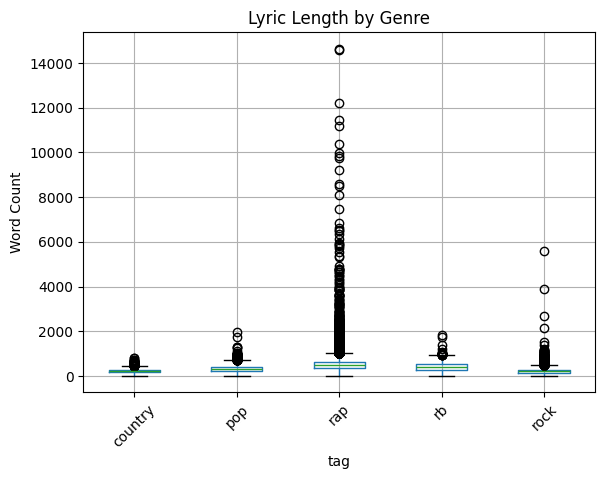

Duplicate lyrics: 123


In [ ]:
# Preprocessing

# Remove Missing Lyrics and Tags
print(df.isnull().sum())
df = df.dropna(subset=[TEXT_COL, TAG_COL])

# Clean Empty Lyrics
df = df[df[TEXT_COL].str.strip() != ""]

# Outliers can skew TF-IDF because of bias towards long songs: Lyric Length Box-Plot
plt.figure(figsize=(12, 6))
df.boxplot(column="lyric_length", by=TAG_COL, rot=45)
plt.title("Lyric Length by Genre")
plt.suptitle("")
plt.ylabel("Word Count")
plt.show()

# Remove Extreme Outliers
lower = df["lyric_length"].quantile(0.01)
upper = df["lyric_length"].quantile(0.99)

# Remove the 1st and 99th percentiles to reduce noise and keep most of the data.
df = df[(df["lyric_length"] >= lower) & (df["lyric_length"] <= upper)]

# Detect Duplicates in the Dataset
duplicates = df.duplicated(subset=[TEXT_COL])
print("Duplicate lyrics:", duplicates.sum())

# Remove Duplicates
df = df.drop_duplicates(subset=[TEXT_COL])

# Initialize lemmatizer and retrieve stop words
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove structural annotations (e.g [Chorus], [Verse], etc)
    text = re.sub(r"\[.*?\]", "", text)

    # Remove punctuation & numbers
    text = re.sub(r"[^a-z\s]", "", text)

    # Tokenize (split sentences into indivial words)
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize (reduce words to their base form)
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join back the output
    return " ".join(words)

# Clean the lyrics in the dataset (Use this dataframe for TF-IDF)
df["clean_lyrics"] = df["lyrics"].apply(preprocess_text)

# TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=50000, # limit features to keep only the most important phrases and speed up training
    ngram_range=(1, 2), # use big grams to extract meaning and better detect song lyrics
    min_df=3,
    max_df=0.93,
    stop_words='english',
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['clean_lyrics'])

# Grid Search

In [ ]:
# Used to track the best performing models for the ensemble later
best_models = {}
scores = {}

# Class Balancing & Training



*   Class weights don't change the class sizes in any way, they improve the way models learn by preventing majority class biases.


In [ ]:
y = df['tag']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

# The class_weight parameter is not available for Naive Bayes or XGBoost
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


# Logistic Regression

Fitting 3 folds for each of 1 candidates, totalling 3 fits


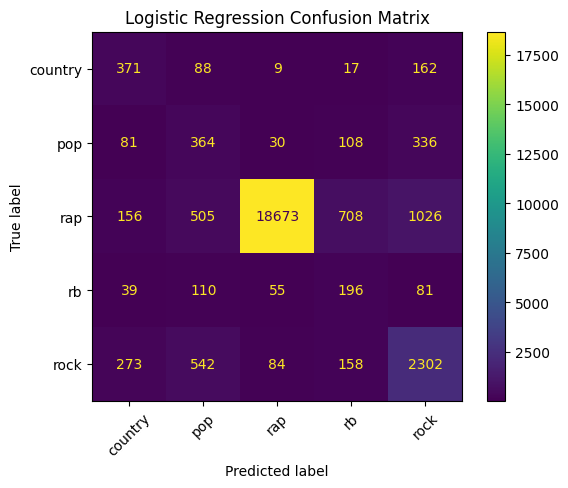


=== Logistic Regression ===
Train Accuracy: 0.8938844504882241

Best Params for log_reg: {'C': 1, 'max_iter': 3000}
Best CV Recall: 0.8222

Validation Accuracy: 0.8275
Classification Report:
              precision    recall  f1-score   support

     country       0.40      0.57      0.47       647
         pop       0.23      0.40      0.29       919
         rap       0.99      0.89      0.94     21068
          rb       0.17      0.41      0.24       481
        rock       0.59      0.69      0.63      3359

    accuracy                           0.83     26474
   macro avg       0.47      0.59      0.51     26474
weighted avg       0.88      0.83      0.85     26474






In [ ]:
logreg = LogisticRegression(random_state=28, class_weight='balanced', n_jobs=-1)

# Tested Parameters are commented while the current best is used
logreg_params = {
    'max_iter': [3000], # 1000, 500, 750, 1500, 2000, 5000
    'C': [1], # 0.1, 0.5, 4, 1, 2
}

log_reg_search = GridSearchCV(
    estimator=logreg,
    param_grid=logreg_params,
    cv=3,
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=3
  )

log_reg_search.fit(X_train, y_train)
best_models['Logistic Regression'] = log_reg_search.best_estimator_
y_pred = best_models['Logistic Regression'].predict(X_test)

#Confusion Matrix#
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_models['Logistic Regression'].classes_)
disp.plot(xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print("\n=== Logistic Regression ===")
print("Train Accuracy: " + str(log_reg_search.score(X_train, y_train)))
print(f'\nBest Params for log_reg: {log_reg_search.best_params_}')
print(f'Best CV Recall: {log_reg_search.best_score_:.4f}\n')

print(f'Validation Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print("\n\n")

scores["Logistic Regression"] = accuracy_score(y_test, y_pred)


# Naive Bayes

Fitting 3 folds for each of 1 candidates, totalling 3 fits


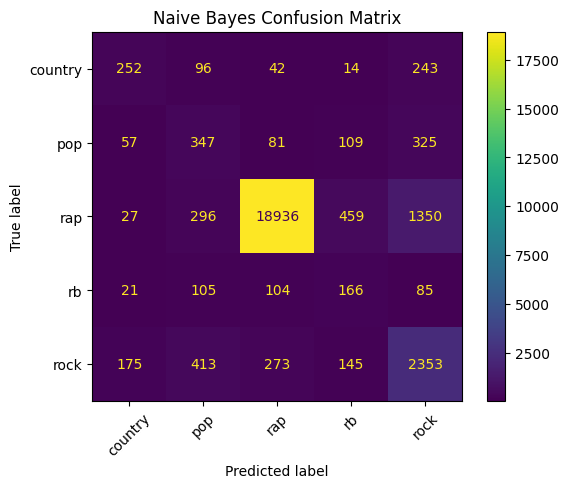


=== Naive Bayes ===
Train Accuracy: 0.8911269760326365

Best Params for nb: {'alpha': 0.01, 'fit_prior': True}
Best CV Recall: 0.8403

Validation Accuracy: 0.8330
Classification Report:
              precision    recall  f1-score   support

     country       0.47      0.39      0.43       647
         pop       0.28      0.38      0.32       919
         rap       0.97      0.90      0.94     21068
          rb       0.19      0.35      0.24       481
        rock       0.54      0.70      0.61      3359

    accuracy                           0.83     26474
   macro avg       0.49      0.54      0.51     26474
weighted avg       0.87      0.83      0.85     26474






In [ ]:
nb = MultinomialNB()

# Tested Parameters are commented while the current best is used
nb_params = {
    "alpha": [0.01], # 0.1, 0.5, 1.0, 2.0
    "fit_prior": [True] # False
}

nb_search = GridSearchCV(
    estimator=nb,
    param_grid=nb_params,
    cv=3,
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=3
  )

nb_search.fit(X_train, y_train, sample_weight=sample_weights)
best_models['Naive Bayes'] = nb_search.best_estimator_
y_pred = best_models['Naive Bayes'].predict(X_test)

#Confusion Matrix#
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_models['Naive Bayes'].classes_
)
disp.plot(xticks_rotation=45)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

print("\n=== Naive Bayes ===")
print("Train Accuracy: " + str(nb_search.score(X_train, y_train)))
print(f'\nBest Params for nb: {nb_search.best_params_}')
print(f'Best CV Recall: {nb_search.best_score_:.4f}\n')


print(f'Validation Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print("\n\n")

scores["Naive Bayes"] = accuracy_score(y_test, y_pred)

# LinearSVM

Fitting 3 folds for each of 1 candidates, totalling 3 fits


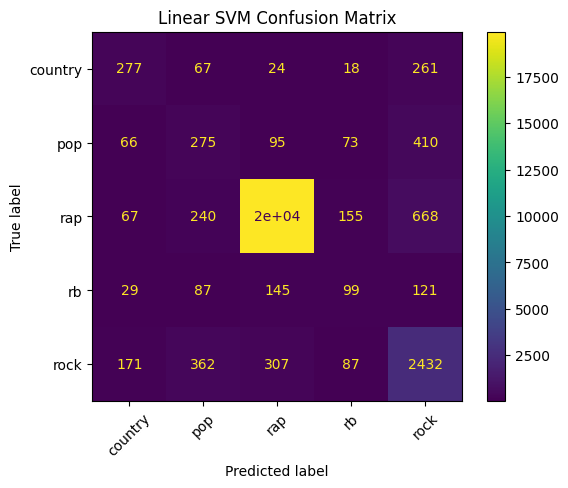


=== Linear SVM ===
Train Accuracy: 0.9768825429202788

Best Params for lin_svm: {'C': 1, 'loss': 'squared_hinge', 'max_iter': 1000}
Best CV Recall: 0.8649

Validation Accuracy: 0.8696
Classification Report:
              precision    recall  f1-score   support

     country       0.45      0.43      0.44       647
         pop       0.27      0.30      0.28       919
         rap       0.97      0.95      0.96     21068
          rb       0.23      0.21      0.22       481
        rock       0.62      0.72      0.67      3359

    accuracy                           0.87     26474
   macro avg       0.51      0.52      0.51     26474
weighted avg       0.88      0.87      0.87     26474






In [ ]:
lin_svm = LinearSVC(class_weight='balanced')

# Tested Parameters are commented while the current best is used
lin_svm_params = {
    "C": [1], # 0.01, 0.1, 10
    "loss": ["squared_hinge"], # hinge
    "max_iter": [1000] # 3000, 5000
}

svm_search = GridSearchCV(
    estimator=lin_svm,
    param_grid=lin_svm_params,
    cv=3,
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=3
  )

svm_search.fit(X_train, y_train)
best_models['Linear SVM'] = svm_search.best_estimator_
y_pred = best_models['Linear SVM'].predict(X_test)

#Confusion Matrix#
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_models['Linear SVM'].classes_
)
disp.plot(xticks_rotation=45)
plt.title("Linear SVM Confusion Matrix")
plt.show()

print("\n=== Linear SVM ===")
print("Train Accuracy: " + str(svm_search.score(X_train, y_train)))
print(f'\nBest Params for lin_svm: {svm_search.best_params_}')
print(f'Best CV Recall: {svm_search.best_score_:.4f}\n')

print(f'Validation Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print("\n\n")

scores["LinearSVM"] = accuracy_score(y_test, y_pred)

# Transformer (DistilBERT)

* The Transformer model doesn't need to train on the full dataset, so a smaller dataset is prepared.


In [ ]:
# Transformers are computationally expensive, so we limit the data size
df_small = df.sample(100000, random_state=42)

dataset = Dataset.from_pandas(df_small[['clean_lyrics', 'tag']])
dataset = dataset.rename_column("clean_lyrics", "text")
dataset = dataset.rename_column("tag", "label")

# Encode labels
labels = dataset.unique("label")
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

dataset = dataset.map(lambda x: {"label": label2id[x["label"]]})

# Tokenize text
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128) # truncation cuts off long text, short text are padded to a fixed length

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.train_test_split(test_size=0.2)

# Pretrained Model
transformer = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(labels)
)

# Training
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16, # number of samples per training step
    per_device_eval_batch_size=8,
    num_train_epochs=2,  # number of full passes through dataset
    logging_steps=100,
    save_strategy="no"
)

trainer = Trainer(
    model=transformer,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)

trainer.train()

best_models['Transformer'] = transformer

# Evaluation
preds = trainer.predict(dataset["test"])
# Convert raw model outputs into predicted class indices
y_pred = preds.predictions.argmax(axis=1)
#
y_true = preds.label_ids


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.585888
200,0.484666
300,0.410980
400,0.452967
500,0.391661
600,0.413776
700,0.393417
800,0.428981
900,0.380435
1000,0.390948


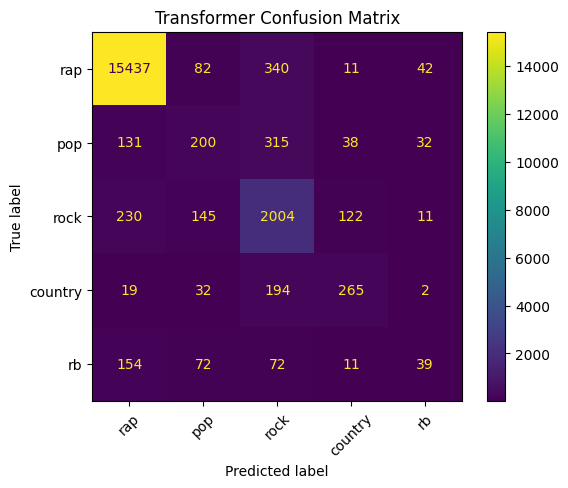

Transformer Accuracy: 0.89725
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     15912
           1       0.38      0.28      0.32       716
           2       0.69      0.80      0.74      2512
           3       0.59      0.52      0.55       512
           4       0.31      0.11      0.16       348

    accuracy                           0.90     20000
   macro avg       0.59      0.54      0.55     20000
weighted avg       0.89      0.90      0.89     20000






In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(id2label.values())
)
disp.plot(xticks_rotation=45)
plt.title("Transformer Confusion Matrix")
plt.show()

print("Transformer Accuracy:", accuracy_score(y_true, y_pred))
print('Classification Report:')
print(classification_report(y_true, y_pred))
print("\n\n")

scores["Transformer"] = accuracy_score(y_true, y_pred)

# Analysis

In [ ]:
print("Overall Accuracy Comparison:")
for name, acc in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<25} {acc:.4f}")

Overall Accuracy Comparison:
  Transformer               0.8972
  LinearSVM                 0.8696
  Naive Bayes               0.8330
  Logistic Regression       0.8275


In [ ]:
# Genre-Specific Anaylsis
feature_names = vectorizer.get_feature_names_out()

# Use Logistic Regression for TF-IDF Interpretation
model = best_models['Logistic Regression']

# extract important words per genre (e.g "rap: wealth, glock, skimask")
for i, genre in enumerate(model.classes_):
    top_indices = np.argsort(model.coef_[i])[-10:]
    top_words = [feature_names[j] for j in top_indices]
    print(genre, top_words)

# Average TF-IDF per genre
genre_means = {}

for genre in y.unique():
    mask = (y == genre).values
    genre_matrix = X[mask]

    mean_vec = genre_matrix.mean(axis=0)  # stays sparse-friendly
    genre_means[genre] = np.asarray(mean_vec).ravel()

genre_means = pd.DataFrame.from_dict(genre_means, orient='index', columns=feature_names)

for genre in genre_means.index:
    print(f"\n=== Top TF-IDF words for: {genre} ===")
    print(genre_means.loc[genre].sort_values(ascending=False).head(10).to_string())

country ['guitar', 'porch', 'country', 'heartache', 'beer', 'truck', 'whiskey', 'little', 'kid rock', 'old']
pop ['bore', 'escape', 'im breathing', 'autumn', 'heehee', 'christmas time', 'elephant', 'hoohoo', 'hee', 'boy']
rap ['cuz', 'imma', 'im', 'yo', 'like', 'bitch', 'rap', 'shit', 'verse', 'nigga']
rb ['body', 'girl', 'ooh', 'club', 'nigga', 'ghetto', 'baby', 'yo', 'yall', 'gon']
rock ['aint got', 'alive', 'death', 'goddamn', 'bleeding', 'head', 'theyre', 'dead', 'street', 'rock roll']

=== Top TF-IDF words for: rap ===
im       0.059498
nigga    0.045886
like     0.045036
got      0.029321
dont     0.027930
know     0.025491
aint     0.024904
shit     0.023564
bitch    0.022137
cause    0.020412

=== Top TF-IDF words for: rb ===
love     0.047094
baby     0.045204
oh       0.040763
yeah     0.031736
girl     0.029671
im       0.029285
know     0.029025
dont     0.026474
youre    0.023197
let      0.022101

=== Top TF-IDF words for: rock ===
oh       0.025216
im       0.022455
love